# Challenge 1: Geodemographic Classification

In this challenge, you will replicate the process of creating a geodemographic classification using the k-means clustering algorithm. Please select any city in the UK except London, Liverpool, or Glasgow. The main goal is to generate a meaningful and informative classification that captures the diversity of areas in your dataset using the census data ( For England, you can try to use the 2021 or 2011 census, and for Scotland, you need to use the 2011 census data) 

1. Define the main goal for the geodemographic classification (marketing, retail and service planning). 
2. Look for census data from the selected city for which you would like to generate the geodemographic classification.
3. The census data at the Output Area OA level. Select multiple topics of at least four topics (socio-demographics, economics, health, and so on). Describe your topic selection accordingly based on the goal of your geodemographic classification. For example, if your geodemographics are related to marketing, Economic variables might be the appropriate selection. 
4. Identify the variables that will be crucial for effectively segmenting neighbourhoods. Evaluate how this choice may impact the classification results, including a DEA analysis.
5. Prepare, adjust or clean the dataset addressing any missing values or outliers that could distort the clustering results.
6. Include standardisation between areas and variables. Make an appropriate analysis and adjust the variable selection accordingly for any multicollinearity.
7. Utilize the k-means clustering algorithm to create a classification based on the selected variables.
8. Define the optimum number of clusters (i.e., using the Elblow method). Experiment with different values of k.
9. Evaluate your cluster groups (e.g., using PCA) and interpret your cluster centres. Describe your results and repeat the process to adjust the variable selection and cluster groups to provide more meaningful results for your geodemographic goal. Interpret the characteristics of each cluster. What demographic patterns or similarities are prevalent within each group?
10. Map the final cluster groups
11. Finish the analysis by naming the final clusters and plotting a final map that includes the census values and the provided names.
12. Finally, acknowledge the subjective nature of classification and make analytical decisions to produce an optimum classification for your specific purpose. Reflect on the challenges and insights gained during the classification process. Ensure you document your analytical decisions and the rationale behind any important decision. Once your geodemographics are constructed, describe the potential use cases for the geodemographic classification you have built based on your initial goal.

In [ ]:
#identifying variables to work with for a marketing analysis

* KS102SC - Age structure - Demographics
* KS103SC - Marital and civil partnership status - Demographics
* KS209SCb - Religion - Demographics
* QS104SC - Sex - Demographics
* QS501SC - Highest level of qualification - Education
* KS105SC - Household composition - Households
* QS302SC - General Health - Health
* KS601SC - Economic activity - Economic 
* KS605SC - Industry - Economic 


Patias, N., Rowe, F. and Arribas‐Bel, D., 2022. Trajectories of neighbourhood inequality in Britain: Unpacking inter‐regional socioeconomic imbalances, 1971− 2011. The Geographical Journal, 188(2), pp.150-165.

In [ ]:
#preparing the data

In [76]:
#reading in selected raw census data (csv files)
import pandas as pd
import os

csv_directory = "data/aberdeen_data"

csv_files = [file for file in os.listdir(csv_directory) if file.endswith(".csv")]

# an empty DataFrame to store the merged data
merged_data = pd.DataFrame()

In [77]:
#merging the csv files
for csv_file in csv_files:
    csv_path = os.path.join(csv_directory, csv_file)
    df_csv = pd.read_csv(csv_path, low_memory=False)
    merged_data = pd.concat([merged_data, df_csv], axis=1)

merged_data.to_csv("data/aberdeen_data/merged_data.csv", index=False)

In [78]:
#checking out first few columns of merged variables
merged_data.head()

,oa_code,All people,0 to 4,5 to 7,8 to 9,10 to 14,15,16 to 17,18 to 19,20 to 24,...,Jewish,Muslim,Sikh,Other religion,No religion,Religion not stated,oa_code,All people,Males,Females
0,S92000003,"5,295,403","292,821","164,246","105,371","291,615","62,278","126,266","142,282","363,940",...,"5,887","76,737","9,055","15,196","1,941,116","368,039",S92000003,"5,295,403","2,567,444","2,727,959"
1,S00088956,230,28,22,6,13,2,4,6,10,...,-,-,-,-,87,11,S00088956,230,111,119
2,S00088957,66,2,1,1,4,-,3,2,4,...,-,3,-,-,21,1,S00088957,66,33,33
3,S00088958,90,3,8,7,12,-,2,3,2,...,-,11,-,-,33,5,S00088958,90,38,52
4,S00088959,83,8,7,3,2,-,1,1,4,...,-,-,-,-,46,10,S00088959,83,44,39


In [79]:
merged_data.columns

Index(['oa_code', 'All people', '0 to 4', '5 to 7', '8 to 9', '10 to 14', '15',
       '16 to 17', '18 to 19', '20 to 24',
       ...
       'Jewish', 'Muslim', 'Sikh', 'Other religion', 'No religion',
       'Religion not stated', 'oa_code', 'All people', 'Males', 'Females'],
      dtype='object', length=119)

In [80]:
#cleaning up the data

keep_cols= [
    'oa_code',
    'All people',
    '16 to 17',
    '18 to 19',
    '20 to 24',
    '25 to 29',
    '30 to 44',
    '45 to 59',
    '60 to 64',
    'Mean age',
    'Median age',
    'All people aged 16 to 74',
    'Economically active: Employee: Part-time',
    'Economically active: Employee: Full-time',
    'Economically active: Self-employed',
    'Unemployed people aged 16 to 74: Long-term unemployed',
    'Very good health',
    'Good health',
    'Fair health',
    'All people aged 16 and over',
    'All people aged 16 and over: Level 3',
    'All people aged 16 and over: Level 4 and above',
    'All people aged 16 to 74 in employment',
    'A. Agriculture forestry and fishing', 
    'B. Mining and quarrying',
    'F. Construction',
    'G. Wholesale and retail trade repair of motor vehicles and motorcycles',
    'H. Transport and storage',
    'J. Information and communication',
    'Males',
    'Females'
]

sorted_merged_data = merged_data[keep_cols]

In [81]:
# for more easy manipulation we define short column names
short_column_names = {
    'Economically active: Employee: Part-time': 'Econ_act_pt',
    'Economically active: Employee: Full-time': 'Econ_act_ft',
    'Economically active: Self-employed': 'Econ_act_se',
    'Very good health': 'Vgd_hlth',
    'Good health': 'Gd_hlth',
    'Fair health': 'Fr_hlth',
    'All people aged 16 and over: Level 3': 'Adult_Lvl3',
    'All people aged 16 and over: Level 4 and above': 'Adult_Lvl4',
    'A. Agriculture forestry and fishing': 'A_Agric', 
    'B. Mining and quarrying': 'B_Mining',
    'F. Construction': 'F_Construct',
    'G. Wholesale and retail trade repair of motor vehicles and motorcycles': 'G_Motor',
    'H. Transport and storage': 'H_Trans',
    'J. Information and communication': 'J_Info'
}

shortened_df = sorted_merged_data.rename(columns=short_column_names)

In [82]:
shortened_df.head()

,oa_code,oa_code,oa_code,oa_code,oa_code,oa_code,oa_code,oa_code,oa_code,All people,...,Adult_Lvl4,All people aged 16 to 74 in employment,A_Agric,B_Mining,F_Construct,G_Motor,H_Trans,J_Info,Males,Females
0,S92000003,S92000003,S92000003,S92000003,S92000003,S92000003,S92000003,S92000003,S92000003,"5,295,403",...,"1,142,662",2516895,41902,33980,200343,376622,125111,69014,"2,567,444","2,727,959"
1,S00088956,S00088956,S00088956,S00088956,S00088956,S00088956,S00088956,S00088956,S00088956,230,...,72,117,0,15,8,15,4,4,111,119
2,S00088957,S00088957,S00088957,S00088957,S00088957,S00088957,S00088957,S00088957,S00088957,66,...,21,40,3,4,0,5,3,0,33,33
3,S00088958,S00088958,S00088958,S00088958,S00088958,S00088958,S00088958,S00088958,S00088958,90,...,43,41,0,6,1,8,1,1,38,52
4,S00088959,S00088959,S00088959,S00088959,S00088959,S00088959,S00088959,S00088959,S00088959,83,...,30,43,2,5,4,5,2,2,44,39


In [83]:
#removing any duplicates from this dataframe
merged_df = shortened_df.loc[:, ~shortened_df.columns.duplicated()]
merged_df.columns.tolist()
#saving this as a new dataframe
merged_df.to_csv("data/aberdeen_data/merged_df.csv", index=False)
merged_df.head()

,oa_code,All people,16 to 17,18 to 19,20 to 24,25 to 29,30 to 44,45 to 59,60 to 64,Mean age,...,Adult_Lvl4,All people aged 16 to 74 in employment,A_Agric,B_Mining,F_Construct,G_Motor,H_Trans,J_Info,Males,Females
0,S92000003,"5,295,403","126,266","142,282","363,940","345,632","1,056,449","1,117,647","336,522",40.3,...,"1,142,662",2516895,41902,33980,200343,376622,125111,69014,"2,567,444","2,727,959"
1,S00088956,230,4,6,10,12,67,38,5,30.8,...,72,117,0,15,8,15,4,4,111,119
2,S00088957,66,3,2,4,4,9,20,4,42.8,...,21,40,3,4,0,5,3,0,33,33
3,S00088958,90,2,3,2,1,19,26,1,32.2,...,43,41,0,6,1,8,1,1,38,52
4,S00088959,83,1,1,4,4,21,19,7,35.9,...,30,43,2,5,4,5,2,2,44,39


In [84]:
#merging the census data with the output area shapefile for Aberdeen's neighbourhoods
import pandas as pd
import geopandas as gpd

shp_path = "data/aberdeen_data/OutputArea2011_MHW.shp"
gdf = gpd.read_file(shp_path)
gdf.head()

,OBJECTID,code,HHcount,Popcount,council,sqkm,hect,masterpc,easting,northing,SHAPE_1_Le,SHAPE_1_Ar,DataZone,geometry
0,1,S00089001,55,115,S12000033,0.029184,2.918398,AB11 7XY,393374,805012,929.786180,29183.980141,S01006594,"POLYGON ((393393 805102, 393384 805051, 393441..."
1,2,S00090016,50,100,S12000033,0.017122,1.712225,AB16 7SX,389779,808556,745.621044,17122.247009,S01006720,"POLYGON ((389796 808485.001, 389817 808466, 38..."
2,3,S00089741,45,109,S12000033,0.045336,4.533582,AB15 4AH,391312,805970,1156.172057,45335.819961,S01006572,"POLYGON ((391410.771 806073.119, 391383.319 80..."
3,4,S00088978,33,60,S12000033,0.033488,3.348824,AB10 1SB,393473,806017,1173.627495,33488.237428,S01006585,"POLYGON ((393596.593 806042.095, 393651 806003..."
4,5,S00090442,64,97,S12000033,0.012945,1.294538,AB24 1TA,394564,808271,615.199658,12945.377768,S01006667,"POLYGON ((394659 808248, 394611.964 808248.964..."


In [85]:
#reducing the geodataframe to only include Aberdeen city's output areas
filtered_gdf = gdf[gdf['council'] == 'S12000033']
filtered_gdf.head()

,OBJECTID,code,HHcount,Popcount,council,sqkm,hect,masterpc,easting,northing,SHAPE_1_Le,SHAPE_1_Ar,DataZone,geometry
0,1,S00089001,55,115,S12000033,0.029184,2.918398,AB11 7XY,393374,805012,929.786180,29183.980141,S01006594,"POLYGON ((393393 805102, 393384 805051, 393441..."
1,2,S00090016,50,100,S12000033,0.017122,1.712225,AB16 7SX,389779,808556,745.621044,17122.247009,S01006720,"POLYGON ((389796 808485.001, 389817 808466, 38..."
2,3,S00089741,45,109,S12000033,0.045336,4.533582,AB15 4AH,391312,805970,1156.172057,45335.819961,S01006572,"POLYGON ((391410.771 806073.119, 391383.319 80..."
3,4,S00088978,33,60,S12000033,0.033488,3.348824,AB10 1SB,393473,806017,1173.627495,33488.237428,S01006585,"POLYGON ((393596.593 806042.095, 393651 806003..."
4,5,S00090442,64,97,S12000033,0.012945,1.294538,AB24 1TA,394564,808271,615.199658,12945.377768,S01006667,"POLYGON ((394659 808248, 394611.964 808248.964..."


In [86]:
#checking we have reduced the size of the geodataframe
#before filtering
gdf.shape

(46351, 14)

In [87]:
#after filtering
filtered_gdf.shape

(1992, 14)

In [88]:
filtered_gdf.to_file("data/aberdeen_data/gdf.shp", index=False)

In [89]:
#merging the census data with the output area shapefile for Aberdeen's 
gdf_path = "data/aberdeen_data/gdf.shp"
gdf = gpd.read_file(gdf_path, low_memory=False)

csv_path = "data/aberdeen_data/merged_df.csv"
csv_data = pd.read_csv(csv_path, low_memory=False)

# merging the GeoDataFrame with the DataFrame based on the oa_code
merged_data = gdf.merge(csv_data, left_on='code', right_on='oa_code', how='left')
#saving it as a shapefile
merged_data.to_file('data/aberdeen_data/aberdeen_data.shp', index=False)

C:\Users\user\MiniForge\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver ESRI Shapefile does not support open option LOW_MEMORY
  return ogr_read(
C:\Users\user\AppData\Local\Temp\ipykernel_22992\1681449206.py:11: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged_data.to_file('data/aberdeen_data/aberdeen_data.shp', index=False)
C:\Users\user\MiniForge\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'All people aged 16 to 74' to 'All peop_1'
  ogr_write(
C:\Users\user\MiniForge\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Econ_act_pt' to 'Econ_act_p'
  ogr_write(
C:\Users\user\MiniForge\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Econ_act_ft' to 'Econ_act_f'
  ogr_write(
C:\Users\user\MiniForge\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Econ_act_se'

In [90]:
merged_data.plot

In [ ]:
merged_data.explore()

In [ ]:
#running a DEA analysis

In [92]:
#examining full time workers in Aberdeen city
merged_data['Econ_act_ft'].describe()

count     1992
unique      98
top         38
freq        68
Name: Econ_act_ft, dtype: object

In [93]:
#examining part time workers in Aberdeen city
merged_data['Econ_act_pt'].describe()

count     1992
unique      34
top          6
freq       145
Name: Econ_act_pt, dtype: object

In [94]:
#examining citizens who work in agriculture, farming or fishing
merged_data.A_Agric.describe()

count    1992.000000
mean        0.144578
std         0.801293
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        27.000000
Name: A_Agric, dtype: float64

In [95]:
#examining citizens who work in the mining industry
merged_data.B_Mining.describe()

count    1992.000000
mean        5.378514
std         4.434727
min         0.000000
25%         2.000000
50%         4.000000
75%         7.000000
max        32.000000
Name: B_Mining, dtype: float64

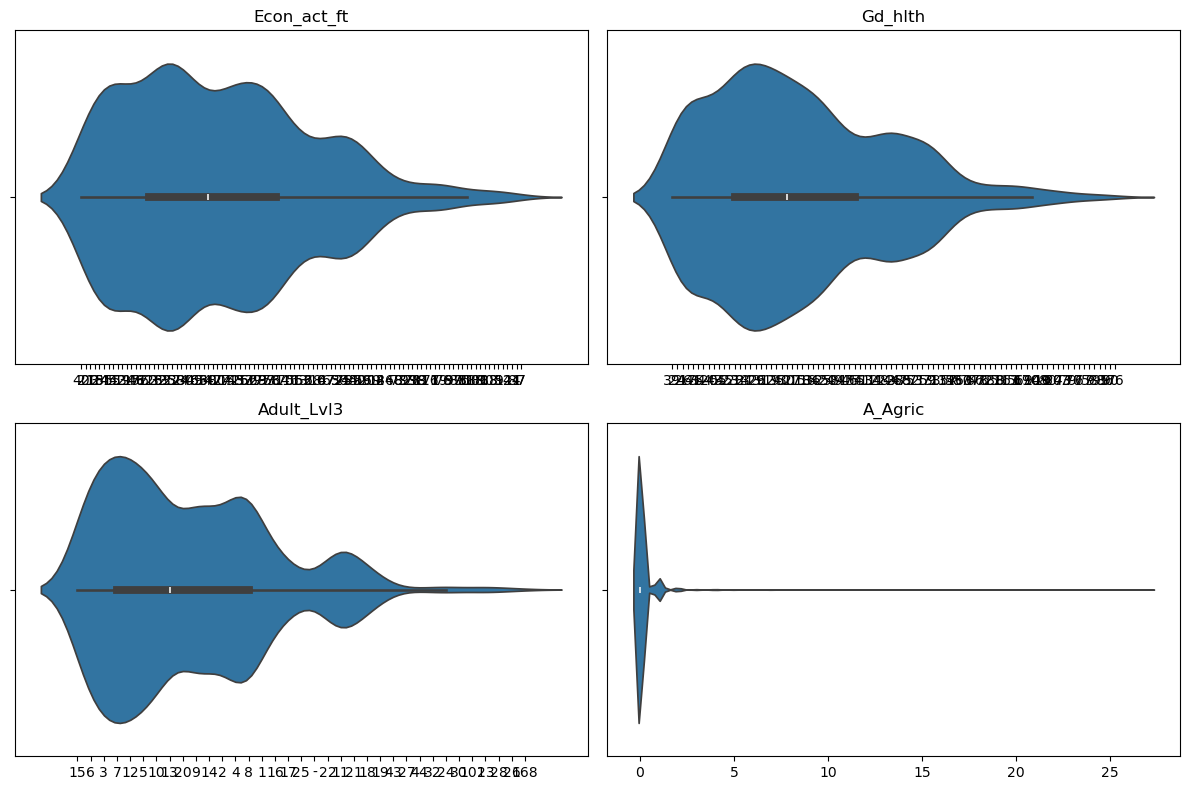

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

attributes_to_plot = ['Econ_act_ft',
                      'Gd_hlth',
                      'Adult_Lvl3',
                      'A_Agric']

plt.figure(figsize=(12, 8))

for i, attribute in enumerate(attributes_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.violinplot(x=merged_data[attribute])
    plt.title(attribute)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

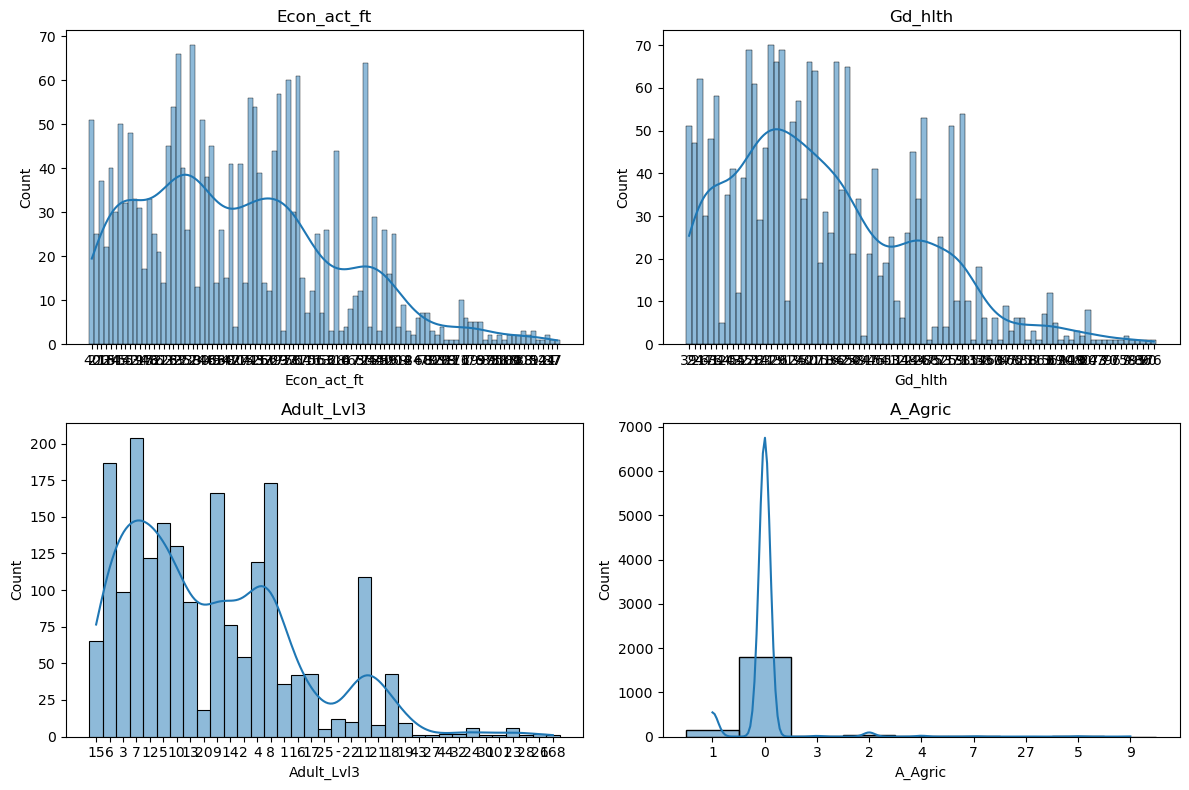

In [97]:
import matplotlib.pyplot as plt

attributes_to_plot = ['Econ_act_ft',
                      'Gd_hlth',
                      'Adult_Lvl3',
                      'A_Agric']

plt.figure(figsize=(12, 8))

for i, attribute in enumerate(attributes_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.histplot(merged_data[attribute].astype(str), kde=True)
    plt.title(attribute)

plt.tight_layout()
plt.show()

In [ ]:
#subsetting the data

In [104]:
#we have already outlined our total columns and value columns
def calculate_percentages(dataframe, total_columns, value_columns):
    result_df = pd.DataFrame()

    for total_col, value_col in zip(total_columns, value_columns):
        percentage_col_name = f"{value_col}_percentage"

        if total_col not in dataframe.columns:
            raise ValueError(f"Total column '{total_col}' not found in the DataFrame.")

        dataframe[value_col] = pd.to_numeric(dataframe[value_col], errors='coerce')
        dataframe[total_col] = pd.to_numeric(dataframe[total_col], errors='coerce')

        result_df[percentage_col_name] = (dataframe[value_col] / dataframe[total_col]) * 100

        result_df[percentage_col_name] = result_df[percentage_col_name].replace([float('inf'), -float('inf')], 0).fillna(0)

    return dataframe.join(result_df)

#list of all the corresponding totals
total_cols = ['All people',
              'All people',
              'All people',
              'All people',
              'All people',
              'All people',
              'All people',
              'All people',
              'All people aged 16 to 74',
              'All people aged 16 to 74',
              'All people aged 16 to 74',
              'All people aged 16 to 74']

#list of the corresponding values. 
value_cols = ['16 to 17',
              '18 to 19',
              '20 to 24',
              '25 to 29',
              '30 to 44',
              '45 to 59',
              '60 to 64',
              'Gd_hlth',
              'Econ_act_pt',
              'Econ_act_ft',
              'Econ_act_se',
              'Unemployed people aged 16 to 74: Long-term unemployed']

result_dataframe = calculate_percentages(merged_data, total_cols, value_cols)

In [105]:
result_dataframe.head()

,OBJECTID,code,HHcount,Popcount,council,sqkm,hect,masterpc,easting,northing,...,20 to 24_percentage,25 to 29_percentage,30 to 44_percentage,45 to 59_percentage,60 to 64_percentage,Gd_hlth_percentage,Econ_act_pt_percentage,Econ_act_ft_percentage,Econ_act_se_percentage,Unemployed people aged 16 to 74: Long-term unemployed_percentage
0,1,S00089001,55,115,S12000033,0.029184,2.918398,AB11 7XY,393374,805012,...,4.347826,4.347826,19.130435,20.869565,11.304348,33.913043,13.186813,43.956044,5.494505,0.000000
1,2,S00090016,50,100,S12000033,0.017122,1.712225,AB16 7SX,389779,808556,...,1.000000,8.000000,21.000000,23.000000,7.000000,24.000000,14.666667,53.333333,1.333333,1.333333
2,3,S00089741,45,109,S12000033,0.045336,4.533582,AB15 4AH,391312,805970,...,1.834862,1.834862,11.009174,24.770642,4.587156,23.853211,16.216216,28.378378,9.459459,1.351351
3,4,S00088978,33,60,S12000033,0.033488,3.348824,AB10 1SB,393473,806017,...,35.000000,11.666667,20.000000,10.000000,6.666667,28.333333,5.555556,42.592593,5.555556,1.851852
4,5,S00090442,64,97,S12000033,0.012945,1.294538,AB24 1TA,394564,808271,...,9.278351,15.463918,20.618557,13.402062,10.309278,42.268041,9.876543,22.222222,3.703704,1.234568


In [106]:
result_dataframe.shape

(1992, 57)

In [1]:
concatenated_df = pd.concat([merged_data, result_dataframe], axis=1, ignore_index=False)
concatenated_df.head()

NameError: name 'pd' is not defined

In [ ]:
#standardising our variables through inverse hyperbolic sine standardisation
import numpy as np

def inverse_hyperbolic_sine_standardisation(x):
    x = pd.to_numeric(x, errors='coerce')  # Convert to number, set non-numeric to NaN
    return np.arcsinh(x) if np.isscalar(x) or x.notna().all() else np.nan 

validated_df_ihs = merged_data.apply(inverse_hyperbolic_sine_standardisation)
validated_df_ihs.head()

In [ ]:
#standardising our variables through range standardisation
import numpy as np

def range_standardisation(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x)) if np.ptp(x) != 0 else 0  # Avoid division by zero

validated_df_range = validated_df_ihs.select_dtypes(include=np.number).apply(range_standardisation, axis=0)
validated_df_range.head()